# ESS11 Data Snapshot – Germany

This notebook provides a first structured overview of the official European Social Survey Round 11 dataset.  
The goal is to inspect the dataset size, available variables, data types, missing values, and a first set of core variables relevant for the capstone project on trust in democracy and political orientation.

## 1. Import libraries

This step loads the Python libraries needed for reading the ESS11 SPSS file, handling tabular data, working with file paths, and exporting results.

In [1]:
pip install pyreadstat pandas openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
conda install -c conda-forge pyreadstat pandas openpyxl

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


## 2. Define file path

This step defines the path to the downloaded ESS11 SPSS file.  
Using `Path()` makes the file path easier to manage across different operating systems and project folders.

## 3. Load ESS11 SPSS data

This step loads the official ESS11 dataset from the `.sav` file.  
`pyreadstat.read_sav()` returns two objects:  
`df` contains the actual survey data, while `meta` contains metadata such as variable labels and value labels.

## 4. Inspect dataset size

This step checks the overall size of the full ESS11 dataset.  
The output shows the number of rows/respondents and the number of columns/variables before filtering by country.

In [3]:
import pandas as pd
import pyreadstat
from pathlib import Path

data_path = Path("../data/raw/ESS11e04_1.sav")

df, meta = pyreadstat.read_sav(data_path)

print("Dataset shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset shape: (50116, 691)
Rows: 50116
Columns: 691


## 5. Check available countries

This step shows how many respondents are included for each country.  
The country variable `cntry` is used to identify Germany and possible comparison countries for later analysis.

In [4]:
df["cntry"].value_counts().sort_index()

cntry
AT    2354
BE    1594
BG    2239
CH    1384
CY     685
DE    2420
EE    1293
ES    1844
FI    1563
FR    1771
GB    1684
GR    2757
HR    1563
HU    2118
IE    2017
IL     906
IS     842
IT    2865
LT    1365
LV    1252
ME    1609
NL    1695
NO    1337
PL    1442
PT    1373
RS    1563
SE    1230
SI    1248
SK    1442
UA    2661
Name: count, dtype: int64

## 6. Filter dataset for Germany

This step creates a Germany-only dataset by filtering the integrated ESS11 dataset where `cntry == "DE"`.  
This Germany subset will be used as the main dataset for the first stage of analysis.

In [5]:
df_de = df[df["cntry"] == "DE"].copy()

print("Germany rows:", df_de.shape[0])
print("Germany columns:", df_de.shape[1])

Germany rows: 2420
Germany columns: 691


## 8. Create a column overview

This step creates an overview table for all variables in the Germany dataset.  
For each variable, it shows the column name, data type, variable label, number and percentage of missing values, and number of unique values.

## 9. Display first variables in the column overview

This step displays the first rows of the variable overview.  
It helps to understand the structure of the dataset and identify potentially relevant variables for the capstone analysis.

In [6]:
columns_snapshot = pd.DataFrame({
    "column": df_de.columns,
    "dtype": [df_de[col].dtype for col in df_de.columns],
    "label": [meta.column_names_to_labels.get(col, "") for col in df_de.columns],
    "missing_count": [df_de[col].isna().sum() for col in df_de.columns],
    "missing_percent": [round(df_de[col].isna().mean() * 100, 2) for col in df_de.columns],
    "unique_values": [df_de[col].nunique(dropna=True) for col in df_de.columns]
})

columns_snapshot.head(50)

,column,dtype,label,missing_count,missing_percent,unique_values
0,name,str,Title of dataset,0,0.00,1
1,essround,float64,ESS round,0,0.00,1
2,edition,str,Edition,0,0.00,1
3,proddate,str,Production date,0,0.00,1
4,idno,float64,Respondent's identification number,0,0.00,2420
5,cntry,str,Country,0,0.00,1
6,dweight,float64,Design weight,0,0.00,20
7,pspwght,float64,Post-stratification weight including design we...,0,0.00,319
8,pweight,float64,Population size weight (must be combined with ...,0,0.00,1
9,anweight,float64,Analysis weight,0,0.00,319


## 10. Generate descriptive statistics for numeric variables

This step creates descriptive statistics for all numeric variables in the Germany dataset.  
The output includes count, mean, standard deviation, minimum, quartiles, and maximum values.

In [7]:
describe_numeric = df_de.describe().T

describe_numeric.head(50)

,count,mean,min,25%,50%,75%,max,std
essround,2420.0,11.0,11.0,11.0,11.0,11.0,11.0,0.0
idno,2420.0,67782.440496,50004.0,58109.25,67615.5,77282.75,86478.0,10754.634848
dweight,2420.0,1.0,0.995869,0.995869,0.995869,0.995869,1.765337,0.019055
pspwght,2420.0,1.0,0.118618,0.259189,0.617519,1.054607,4.342649,1.162002
pweight,2420.0,2.99297,2.99297,2.99297,2.99297,2.99297,2.99297,0.0
anweight,2420.0,2.99297,0.355022,0.775745,1.848217,3.156407,12.997417,3.477836
nwspol,2417.0,234.664046,0.0,30.0,60.0,210.0,1200.0,341.647761
netusoft,2420.0,4.482645,1.0,5.0,5.0,5.0,5.0,1.177906
netustm,2075.0,232.55759,0.0,90.0,180.0,300.0,1440.0,195.431298
ppltrst,2420.0,5.189669,0.0,4.0,5.0,7.0,10.0,2.231343


## 11. Export dataset snapshot to Excel

This step exports the variable overview and descriptive statistics to an Excel file.  
The exported snapshot can be used for variable selection, documentation, and project planning.

In [8]:
output_path = Path("../data/processed/ess11_germany_snapshot.xlsx")

with pd.ExcelWriter(output_path) as writer:
    columns_snapshot.to_excel(writer, sheet_name="columns_overview", index=False)
    describe_numeric.to_excel(writer, sheet_name="describe_numeric")

print(f"Exported to: {output_path}")

Exported to: ../data/processed/ess11_germany_snapshot.xlsx


## 12. Define core variables for the capstone project

This step defines a first set of core variables related to trust in democracy, political orientation, socio-economic situation, education, age, and gender.  
These variables will be used for the initial analytical exploration.

## 13. Preview core variables

This step displays the first rows of the selected core variables.  
It provides a quick check that the variables are available, correctly selected, and plausible in their values.

In [9]:
core_vars = [
    "cntry",
    "trstprl",   # trust in parliament
    "trstplt",   # trust in politicians
    "trstprt",   # trust in political parties
    "stfdem",    # satisfaction with democracy
    "hincfel",   # feeling about household income
    "lrscale",   # left-right placement
    "eduyrs",    # years of education
    "agea",      # age
    "gndr"       # gender
]

df_de[core_vars].head()

,cntry,trstprl,trstplt,trstprt,stfdem,hincfel,lrscale,eduyrs,agea,gndr
8256,DE,7.0,5.0,5.0,8.0,1.0,5.0,17.0,34.0,1.0
8257,DE,4.0,5.0,3.0,7.0,2.0,3.0,17.0,42.0,2.0
8258,DE,8.0,7.0,7.0,5.0,2.0,5.0,5.0,41.0,1.0
8259,DE,7.0,8.0,7.0,8.0,1.0,5.0,13.0,58.0,2.0
8260,DE,7.0,7.0,7.0,8.0,1.0,6.0,17.0,40.0,1.0


## 14. Check missing values in core variables

This step checks how many values are missing for each selected core variable.  
This is important to assess whether the variables are reliable enough for further analysis.

In [10]:
df_de.shape

(2420, 691)

## 15. Check complete cases for core variables

This step checks how many respondents have valid values for all selected core variables.  
The comparison between all German respondents and complete cases indicates how much data would remain if missing values were removed.

In [11]:
df_de[core_vars].dropna().shape

(2267, 10)

In [12]:
print("Germany sample size:", df_de.shape[0])
print("Number of variables:", df_de.shape[1])

Germany sample size: 2420
Number of variables: 691


## 18. Inspect outcome variables

This step focuses on the main outcome variables: trust in parliament, trust in politicians, trust in political parties, and satisfaction with democracy.  
These variables represent the central dimensions of political trust and democratic satisfaction in the project.

In [13]:
df_core = df_de[core_vars].copy()

print("Rows before dropping missing values:", df_core.shape[0])
print("Rows after dropping missing values:", df_core.dropna().shape[0])

Rows before dropping missing values: 2420
Rows after dropping missing values: 2267


In [14]:
missing_core = pd.DataFrame({
    "missing_count": df_core.isna().sum(),
    "missing_percent": round(df_core.isna().mean() * 100, 2)
})

missing_core

,missing_count,missing_percent
cntry,0,0.00
trstprl,18,0.74
trstplt,19,0.79
trstprt,29,1.20
stfdem,21,0.87
hincfel,7,0.29
lrscale,103,4.26
eduyrs,7,0.29
agea,5,0.21
gndr,0,0.00


## 16. Create cleaned core dataset

This step creates a preliminary working dataset that contains only the selected core variables. Missing values are inspected before deciding which rows to remove for specific analyses.

In [15]:
print("Cleaned core dataset shape:", df_core.shape)

df_core.head()

Cleaned core dataset shape: (2420, 10)


,cntry,trstprl,trstplt,trstprt,stfdem,hincfel,lrscale,eduyrs,agea,gndr
8256,DE,7.0,5.0,5.0,8.0,1.0,5.0,17.0,34.0,1.0
8257,DE,4.0,5.0,3.0,7.0,2.0,3.0,17.0,42.0,2.0
8258,DE,8.0,7.0,7.0,5.0,2.0,5.0,5.0,41.0,1.0
8259,DE,7.0,8.0,7.0,8.0,1.0,5.0,13.0,58.0,2.0
8260,DE,7.0,7.0,7.0,8.0,1.0,6.0,17.0,40.0,1.0


## 17. Describe core variables

This step creates descriptive statistics for the cleaned core dataset.
The output helps to understand the distribution, average values, minimum, maximum and spread of the selected variables.

In [16]:
# Overview of core variables
df_core.describe().T

,count,mean,std,min,25%,50%,75%,max
trstprl,2402.0,5.049958,2.660899,0.0,3.0,5.0,7.0,10.0
trstplt,2401.0,4.004165,2.361317,0.0,2.0,4.0,6.0,10.0
trstprt,2391.0,3.974069,2.203306,0.0,2.0,4.0,6.0,10.0
stfdem,2399.0,5.696540,2.550334,0.0,4.0,6.0,8.0,10.0
hincfel,2413.0,1.596353,0.676804,1.0,1.0,2.0,2.0,4.0
lrscale,2317.0,4.548123,1.770499,0.0,3.0,5.0,5.0,10.0
eduyrs,2413.0,14.466639,3.425986,0.0,12.0,14.0,17.0,33.0
agea,2415.0,50.383851,18.997265,15.0,35.0,52.0,65.0,90.0
gndr,2420.0,1.498347,0.500101,1.0,1.0,1.0,2.0,2.0


In [17]:
# Valid sample size for each variable
valid_counts = pd.DataFrame({
    "valid_count": df_core.notna().sum(),
    "missing_count": df_core.isna().sum(),
    "missing_percent": round(df_core.isna().mean() * 100, 2),
    "unique_values": df_core.nunique(dropna=True)
})

valid_counts

,valid_count,missing_count,missing_percent,unique_values
cntry,2420,0,0.00,1
trstprl,2402,18,0.74,11
trstplt,2401,19,0.79,11
trstprt,2391,29,1.20,11
stfdem,2399,21,0.87,11
hincfel,2413,7,0.29,4
lrscale,2317,103,4.26,11
eduyrs,2413,7,0.29,30
agea,2415,5,0.21,76
gndr,2420,0,0.00,2


## 18. Inspect outcome variables

This step focuses on the main outcome variables of the project
trust in parliament, trust in politicians, trust in political parties and satisfaction with democracy.
These variables represent the central dimensions of political trust and democratic satisfaction.


In [18]:
# Valid cases for main outcome variables
outcome_vars = ["trstprl", "trstplt", "trstprt", "stfdem"]

df_de[outcome_vars].notna().sum()

trstprl    2402
trstplt    2401
trstprt    2391
stfdem     2399
dtype: int64

## 19. Check correlations between outcome variables

This step checks how strongly the main outcome variables are related to each other.
High correlations would suggest that institutional trust and democratic satisfaction are connected,
but not necessarily identical concepts.

In [19]:


df_core[outcome_vars].corr()

,trstprl,trstplt,trstprt,stfdem
trstprl,1.000000,0.771613,0.721631,0.653851
trstplt,0.771613,1.000000,0.840480,0.632722
trstprt,0.721631,0.840480,1.000000,0.601777
stfdem,0.653851,0.632722,0.601777,1.000000


## 20. Check relationships between trust and explanatory variables

This step explores first correlations between trust/democratic satisfaction and selected explanatory variables
The explanatory variables include household income feeling, left-right placement, education years and age.
This is an initial exploration and does not yet imply causality.

In [20]:
explanatory_vars = ["hincfel", "lrscale", "eduyrs", "agea"]

analysis_vars = outcome_vars + explanatory_vars

df_core[analysis_vars].corr()

,trstprl,trstplt,trstprt,stfdem,hincfel,lrscale,eduyrs,agea
trstprl,1.000000,0.771613,0.721631,0.653851,-0.182538,-0.195080,0.224896,-0.123936
trstplt,0.771613,1.000000,0.840480,0.632722,-0.170397,-0.175683,0.154994,-0.066447
trstprt,0.721631,0.840480,1.000000,0.601777,-0.139511,-0.141572,0.151442,-0.152002
stfdem,0.653851,0.632722,0.601777,1.000000,-0.194769,-0.162642,0.153029,-0.075538
hincfel,-0.182538,-0.170397,-0.139511,-0.194769,1.000000,0.029836,-0.227703,-0.037525
lrscale,-0.195080,-0.175683,-0.141572,-0.162642,0.029836,1.000000,-0.104152,0.052996
eduyrs,0.224896,0.154994,0.151442,0.153029,-0.227703,-0.104152,1.000000,-0.087068
agea,-0.123936,-0.066447,-0.152002,-0.075538,-0.037525,0.052996,-0.087068,1.000000


## 21. Create simple age groups

This step creates age groups to make group comparisons easier
Instead of analyzing every single age separately, respondents are grouped into broader age categories.

In [21]:

df_core["age_group"] = pd.cut(

    df_core["agea"],

    bins=[17, 29, 44, 59, 120],

    labels=["18-29", "30-44", "45-59", "60+"]

)

df_core[["agea", "age_group"]].head()

,agea,age_group
8256,34.0,30-44
8257,42.0,30-44
8258,41.0,30-44
8259,58.0,45-59
8260,40.0,30-44


## 22. Compare democratic satisfaction by age group

This step compares average satisfaction with democracy across age groups.
It gives a first indication of whether democratic satisfaction differs between younger, middle-aged and older respondents.

In [22]:
df_core.groupby("age_group", observed=False)["stfdem"].agg(

    ["count", "mean", "median", "std"]

).round(2)

,count,mean,median,std
age_group,,,,
18-29,363,6.13,7.0,2.30
30-44,530,5.66,6.0,2.50
45-59,578,5.50,6.0,2.75
60+,855,5.55,6.0,2.54


## 23. Compare trust in parliament by income feeling

This step compares average trust in parliament by respondents' subjective household income situation.
The goal is to explore whether people who feel economically more insecure also show lower levels of institutional trust.
This is an exploratory group comparison and does not imply causality.

In [23]:
df_core.groupby("hincfel")["trstprl"].agg(

    ["count", "mean", "median", "std"]

).round(2)

,count,mean,median,std
hincfel,,,,
1.0,1187,5.50,6.0,2.59
2.0,1026,4.69,5.0,2.60
3.0,142,4.24,4.0,2.89
4.0,40,3.42,3.5,2.92


## 24. Compare democratic satisfaction by left-right placement

This step compares average satisfaction with democracy across the political left-right scale.
The goal is to explore whether democratic satisfaction differs depending on respondents' political self-placement.
This helps identify whether dissatisfaction is concentrated more strongly in specific political orientation groups.

In [24]:
df_core.groupby("lrscale")["stfdem"].agg(

    ["count", "mean", "median", "std"]

).round(2)

,count,mean,median,std
lrscale,,,,
0.0,66,4.71,5.0,2.76
1.0,51,6.24,7.0,2.49
2.0,157,6.55,7.0,2.19
3.0,327,6.48,7.0,2.09
4.0,300,6.32,7.0,2.12
5.0,916,5.43,6.0,2.62
6.0,220,5.58,6.0,2.50
7.0,168,5.02,5.0,2.54
8.0,67,4.97,5.0,2.70


## 25. Export cleaned core dataset

This step exports the cleaned core dataset as a CSV file.
The exported dataset can later be used for further analysis, Tableau dashboards, SQL import, or documentation of the analytical workflow.
This creates a reproducible working dataset based on the selected core variables.

In [25]:
df_core.to_csv("../data/clean/ess11_germany_core_clean.csv", index=False)

print("Exported cleaned core dataset to ../data/ess11_germany_core_clean.csv")

Exported cleaned core dataset to ../data/ess11_germany_core_clean.csv


In [26]:
# Check whether variables containing "vote" exist in the dataset

vote_vars = [col for col in df_de.columns if "vote" in col.lower()]

vote_vars

['vote']

In [27]:
# %% [markdown]
# ## 26. Inspect vote variable
#
# This step checks the meaning, value labels and distribution of the `vote` variable.
# The variable is potentially important because it can connect political trust and democratic satisfaction
# with actual political participation.
#
# Before using it in the analysis, we inspect whether the values represent voting, non-voting,
# ineligibility, or missing/special response categories.

print("Variable label:")
print(meta.column_names_to_labels.get("vote"))

print("\nValue labels:")
print(meta.variable_value_labels.get("vote"))

print("\nDistribution:")
print(df_de["vote"].value_counts(dropna=False).sort_index())

Variable label:
Voted last national election

Value labels:
{1.0: 'Yes', 2.0: 'No', 3.0: 'Not eligible to vote', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
vote
1.0    1906
2.0     254
3.0     255
NaN       5
Name: count, dtype: int64


In [28]:
# %% [markdown]
# ## 27. Clean vote variable
#
# This step creates a cleaned voting variable.
# Only respondents who were eligible to vote are kept for voting-behavior analysis.
# `1 = voted` and `2 = did not vote` are recoded into readable labels.
# Respondents who were not eligible to vote are set to missing for this specific analysis.

df_de["vote_clean"] = df_de["vote"].map({
    1.0: "Voted",
    2.0: "Did not vote"
})

df_de["vote_clean"].value_counts(dropna=False)

vote_clean
Voted           1906
NaN              260
Did not vote     254
Name: count, dtype: int64

In [29]:
# %% [markdown]
# ## 28. Add cleaned vote variable to core variables
#
# This step adds the cleaned voting variable to the selected core variables.
# The cleaned variable allows the analysis to connect political trust and democratic satisfaction
# with actual voting participation among eligible respondents.

core_vars = [
    "cntry",
    "trstprl",       # trust in parliament
    "trstplt",       # trust in politicians
    "trstprt",       # trust in political parties
    "stfdem",        # satisfaction with democracy
    "vote_clean",    # voted or did not vote in last national election
    "hincfel",       # feeling about household income
    "lrscale",       # left-right placement
    "eduyrs",        # years of education
    "agea",          # age
    "gndr"           # gender
]

df_core = df_de[core_vars].dropna().copy()

print("Updated cleaned core dataset shape:", df_core.shape)
df_core.head()

Updated cleaned core dataset shape: (2059, 11)


,cntry,trstprl,trstplt,trstprt,stfdem,vote_clean,hincfel,lrscale,eduyrs,agea,gndr
8256,DE,7.0,5.0,5.0,8.0,Voted,1.0,5.0,17.0,34.0,1.0
8257,DE,4.0,5.0,3.0,7.0,Voted,2.0,3.0,17.0,42.0,2.0
8259,DE,7.0,8.0,7.0,8.0,Voted,1.0,5.0,13.0,58.0,2.0
8260,DE,7.0,7.0,7.0,8.0,Voted,1.0,6.0,17.0,40.0,1.0
8261,DE,8.0,7.0,7.0,9.0,Voted,2.0,3.0,17.0,46.0,1.0


In [30]:
# %% [markdown]
# ## 29. Compare democratic satisfaction by voting behavior
#
# This step compares average satisfaction with democracy between respondents who voted
# and respondents who did not vote in the last national election.
# The goal is to explore whether democratic dissatisfaction is associated with lower political participation.

df_core.groupby("vote_clean")["stfdem"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
vote_clean,,,,
Did not vote,227,4.42,4.0,2.68
Voted,1832,5.76,6.0,2.47


In [31]:
# %% [markdown]
# ## 30. Compare institutional trust by voting behavior
#
# This step compares average trust in parliament, politicians and political parties
# between voters and non-voters.
# This helps assess whether lower institutional trust is associated with democratic disengagement.

df_core.groupby("vote_clean")[["trstprl", "trstplt", "trstprt"]].mean().round(2)

,trstprl,trstplt,trstprt
vote_clean,,,
Did not vote,3.63,2.84,2.91
Voted,5.17,4.11,4.05


## 31. First interpretation: voting behavior and democratic trust

The first group comparisons show clear differences between voters and non-voters.

Respondents who reported that they voted in the last national election show higher average satisfaction with democracy and higher average trust in parliament, politicians and political parties.

The largest difference appears in trust in parliament, followed by satisfaction with democracy, trust in politicians and trust in political parties.

This suggests that political participation is associated with higher democratic satisfaction and institutional trust. However, this is an exploratory association and does not imply causality.

In [32]:
# Calculate group means and differences between voters and non-voters

trust_by_vote = df_core.groupby("vote_clean")[["stfdem", "trstprl", "trstplt", "trstprt"]].mean().round(2)

difference = (
    trust_by_vote.loc["Voted"] - trust_by_vote.loc["Did not vote"]
).round(2)

difference_table = pd.DataFrame({
    "Did not vote": trust_by_vote.loc["Did not vote"],
    "Voted": trust_by_vote.loc["Voted"],
    "Difference (Voted - Did not vote)": difference
})

difference_table

,Did not vote,Voted,Difference (Voted - Did not vote)
stfdem,4.42,5.76,1.34
trstprl,3.63,5.17,1.54
trstplt,2.84,4.11,1.27
trstprt,2.91,4.05,1.14


## 32. Define extended candidate variables

This step defines an extended set of candidate variables for the next stage of the analysis.

The goal is to move beyond the initial trust and democracy variables and include additional dimensions that are relevant for the updated project framing:

- party trust and institutional trust
- political efficacy and perceived responsiveness
- social trust
- voting behavior
- economic security
- political orientation
- socio-demographic context

This helps assess whether the ESS11 dataset can support the refined focus on democratic performance, party trust, political efficacy and social confidence.

In [33]:
new_candidate_vars = [
    "stfdem",
    "trstprl", "trstplt", "trstprt", "trstlgl", "trstplc", "trstep", "trstun",
    "ppltrst", "pplfair", "pplhlp",
    "polintr", "psppsgva", "psppipla", "cptppola", "actrolga",
    "hincfel", "lrscale", "eduyrs", "agea", "gndr",
    "vote", "vote_clean"
]

candidate_overview = pd.DataFrame({
    "column": new_candidate_vars,
    "label": [meta.column_names_to_labels.get(col, "created variable") for col in new_candidate_vars],
    "valid_count": [df_de[col].notna().sum() if col in df_de.columns else df_core[col].notna().sum() for col in new_candidate_vars],
    "missing_count": [df_de[col].isna().sum() if col in df_de.columns else df_core[col].isna().sum() for col in new_candidate_vars],
    "missing_percent": [round(df_de[col].isna().mean() * 100, 2) if col in df_de.columns else round(df_core[col].isna().mean() * 100, 2) for col in new_candidate_vars],
    "unique_values": [df_de[col].nunique(dropna=True) if col in df_de.columns else df_core[col].nunique(dropna=True) for col in new_candidate_vars]
})

candidate_overview

,column,label,valid_count,missing_count,missing_percent,unique_values
0,stfdem,How satisfied with the way democracy works in ...,2399,21,0.87,11
1,trstprl,Trust in country's parliament,2402,18,0.74,11
2,trstplt,Trust in politicians,2401,19,0.79,11
3,trstprt,Trust in political parties,2391,29,1.20,11
4,trstlgl,Trust in the legal system,2401,19,0.79,11
5,trstplc,Trust in the police,2414,6,0.25,11
6,trstep,Trust in the European Parliament,2357,63,2.60,11
7,trstun,Trust in the United Nations,2337,83,3.43,11
8,ppltrst,Most people can be trusted or you can't be too...,2420,0,0.00,11
9,pplfair,"Most people try to take advantage of you, or t...",2418,2,0.08,11


## 33. Inspect value labels of key variables

This step checks the value labels of the most important candidate variables.

This is necessary because many ESS variables use coded numerical scales. Before interpreting means, correlations or building indices, we need to understand what higher and lower values mean.

This is especially important for:

- household income feeling
- political interest
- political efficacy variables
- social trust variables

The output helps decide whether variables can be used directly or need to be recoded.

In [34]:
vars_to_check = [
    "hincfel",
    "polintr",
    "psppsgva",
    "psppipla",
    "cptppola",
    "actrolga",
    "ppltrst",
    "pplfair",
    "pplhlp"
]

for var in vars_to_check:
    print("\n" + "=" * 70)
    print("Variable:", var)
    print("Label:", meta.column_names_to_labels.get(var))
    print("Value labels:", meta.variable_value_labels.get(var))
    print("\nDistribution:")
    print(df_de[var].value_counts(dropna=False).sort_index())


Variable: hincfel
Label: Feeling about household's income nowadays
Value labels: {1.0: 'Living comfortably on present income', 2.0: 'Coping on present income', 3.0: 'Difficult on present income', 4.0: 'Very difficult on present income', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
hincfel
1.0    1196
2.0    1035
3.0     142
4.0      40
NaN       7
Name: count, dtype: int64

Variable: polintr
Label: How interested in politics
Value labels: {1.0: 'Very interested', 2.0: 'Quite interested', 3.0: 'Hardly interested', 4.0: 'Not at all interested', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
polintr
1.0    628
2.0    917
3.0    733
4.0    141
NaN      1
Name: count, dtype: int64

Variable: psppsgva
Label: Political system allows people to have a say in what government does
Value labels: {1.0: 'Not at all', 2.0: 'Very little', 3.0: 'Some', 4.0: 'A lot', 5.0: 'A great deal', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
pspp

## 34. Compare democratic satisfaction and institutional trust

This step compares the average values of democratic satisfaction and different trust variables.

The goal is to explore whether trust in political parties and politicians is lower than trust in other institutions.

This is important for the refined project framing around a possible party-trust gap or democratic performance gap.

The analysis is descriptive and does not imply causality.

In [35]:
trust_vars = [
    "stfdem",
    "trstprl",
    "trstplt",
    "trstprt",
    "trstlgl",
    "trstplc",
    "trstep",
    "trstun"
]

trust_summary = df_de[trust_vars].describe().T[
    ["count", "mean", "std", "min", "50%", "max"]
].round(2)

trust_summary

,count,mean,std,min,50%,max
stfdem,2399.0,5.70,2.55,0.0,6.0,10.0
trstprl,2402.0,5.05,2.66,0.0,5.0,10.0
trstplt,2401.0,4.00,2.36,0.0,4.0,10.0
trstprt,2391.0,3.97,2.20,0.0,4.0,10.0
trstlgl,2401.0,6.37,2.45,0.0,7.0,10.0
trstplc,2414.0,7.12,2.16,0.0,8.0,10.0
trstep,2357.0,4.60,2.51,0.0,5.0,10.0
trstun,2337.0,5.04,2.44,0.0,5.0,10.0


## 35. Create readable labels for trust variables

This step creates readable labels for the trust and democratic satisfaction variables.

These labels make tables and visualizations easier to interpret, especially for the final dashboard or presentation.

The original ESS variable names are technically precise, but they are not always intuitive for audiences.

In [36]:
trust_labels = {
    "stfdem": "Satisfaction with democracy",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties",
    "trstlgl": "Trust in legal system",
    "trstplc": "Trust in police",
    "trstep": "Trust in European Parliament",
    "trstun": "Trust in United Nations"
}

trust_summary_labeled = trust_summary.copy()
trust_summary_labeled["label"] = trust_summary_labeled.index.map(trust_labels)
trust_summary_labeled = trust_summary_labeled[
    ["label", "count", "mean", "std", "min", "50%", "max"]
]

trust_summary_labeled.sort_values("mean")

,label,count,mean,std,min,50%,max
trstprt,Trust in political parties,2391.0,3.97,2.20,0.0,4.0,10.0
trstplt,Trust in politicians,2401.0,4.00,2.36,0.0,4.0,10.0
trstep,Trust in European Parliament,2357.0,4.60,2.51,0.0,5.0,10.0
trstun,Trust in United Nations,2337.0,5.04,2.44,0.0,5.0,10.0
trstprl,Trust in parliament,2402.0,5.05,2.66,0.0,5.0,10.0
stfdem,Satisfaction with democracy,2399.0,5.70,2.55,0.0,6.0,10.0
trstlgl,Trust in legal system,2401.0,6.37,2.45,0.0,7.0,10.0
trstplc,Trust in police,2414.0,7.12,2.16,0.0,8.0,10.0


## 36. Visualize the party-trust and institutional-trust gap (initial rough visualization)

This step creates a first bar chart comparing democratic satisfaction and trust in different institutions.

The aim is to visually inspect whether trust in political parties and politicians is lower than trust in other institutions.

This directly supports the refined storyline around a possible performance gap or party-trust gap.

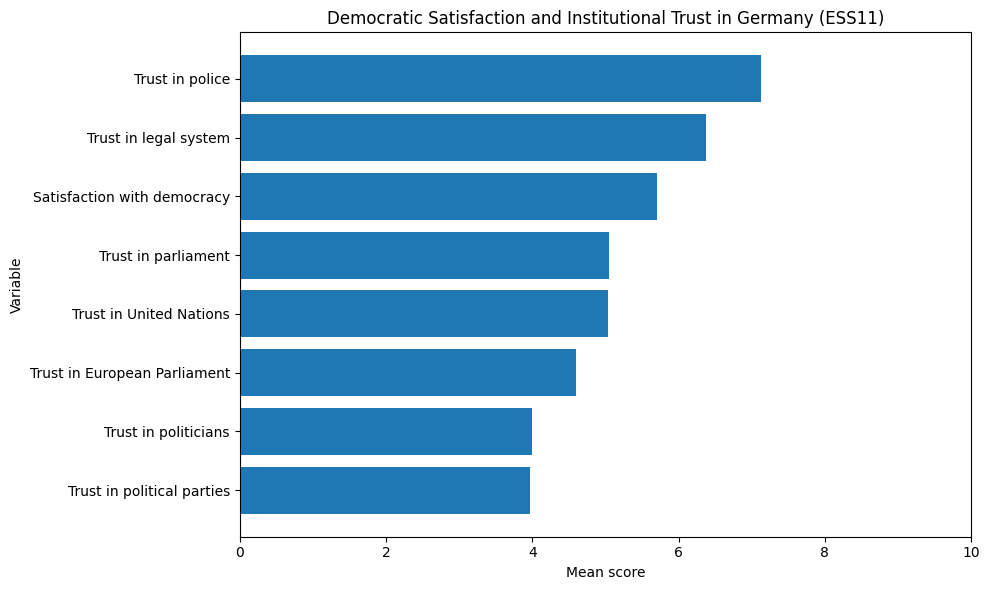

In [37]:
import matplotlib.pyplot as plt

plot_data = trust_summary_labeled.sort_values("mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_data["label"], plot_data["mean"])
plt.xlabel("Mean score")
plt.ylabel("Variable")
plt.title("Democratic Satisfaction and Institutional Trust in Germany (ESS11)")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

## 37. Check relationship between social trust and democratic trust

This step explores whether social trust is associated with democratic satisfaction and institutional trust.

The social trust variables are used as proxies for broader assumptions about whether people see others as trustworthy, fair and helpful.

This is relevant for the conceptual extension inspired by the idea that democratic confidence may be linked to broader social confidence.

This analysis is exploratory and does not prove causality.

In [38]:
social_trust_vars = ["ppltrst", "pplfair", "pplhlp"]
political_trust_vars = ["stfdem", "trstprl", "trstplt", "trstprt"]

social_political_corr = df_de[
    social_trust_vars + political_trust_vars
].corr().round(2)

social_political_corr

,ppltrst,pplfair,pplhlp,stfdem,trstprl,trstplt,trstprt
ppltrst,1.00,0.47,0.38,0.29,0.33,0.34,0.31
pplfair,0.47,1.00,0.42,0.28,0.28,0.30,0.29
pplhlp,0.38,0.42,1.00,0.24,0.26,0.30,0.28
stfdem,0.29,0.28,0.24,1.00,0.65,0.63,0.60
trstprl,0.33,0.28,0.26,0.65,1.00,0.77,0.72
trstplt,0.34,0.30,0.30,0.63,0.77,1.00,0.84
trstprt,0.31,0.29,0.28,0.60,0.72,0.84,1.00


## 38. Create a social trust index

This step creates a simple social trust index based on three ESS variables:

- whether most people can be trusted
- whether most people try to be fair
- whether most people are helpful

The index is calculated as the average of the three variables.

This index is used as a proxy for social confidence. It does not directly measure a philosophical view of human nature, but it helps analyze whether trust in people is associated with democratic trust.

In [39]:
df_de["social_trust_index"] = df_de[["ppltrst", "pplfair", "pplhlp"]].mean(axis=1)

df_de["social_trust_index"].describe()

count    2420.000000
mean        5.567011
std         1.642011
min         0.000000
25%         4.666667
50%         5.666667
75%         6.666667
max        10.000000
Name: social_trust_index, dtype: float64

## 39. Create social trust groups

This step divides respondents into three groups based on their social trust index:

- low social trust
- medium social trust
- high social trust

The goal is to compare democratic satisfaction and institutional trust across social trust groups.

This makes the analysis easier to interpret than using only continuous correlation values.

In [40]:
df_de["social_trust_group"] = pd.qcut(
    df_de["social_trust_index"],
    q=3,
    labels=["Low social trust", "Medium social trust", "High social trust"]
)

df_de["social_trust_group"].value_counts(dropna=False)

social_trust_group
Low social trust       900
Medium social trust    777
High social trust      743
Name: count, dtype: int64

## 40. Compare democratic trust by social trust group

This step compares democratic satisfaction and institutional trust across low, medium and high social trust groups.

The goal is to test whether people with higher social trust also show higher democratic satisfaction and higher trust in political institutions.

This supports the broader question of whether democratic confidence is connected to social confidence.

In [41]:
df_de.groupby("social_trust_group", observed=False)[
    ["stfdem", "trstprl", "trstplt", "trstprt"]
].agg(["count", "mean", "median", "std"]).round(2)

stfdem                    trstprl                     \
                     count  mean median   std   count  mean median   std   
social_trust_group                                                         
Low social trust       888  4.70    5.0  2.72     894  3.93    4.0  2.67   
Medium social trust    771  5.96    6.0  2.28     769  5.40    6.0  2.42   
High social trust      740  6.61    7.0  2.16     739  6.04    6.0  2.39   

                    trstplt                    trstprt                     
                      count  mean median   std   count  mean median   std  
social_trust_group                                                         
Low social trust        892  2.96    3.0  2.31     888  3.07    3.0  2.21  
Medium social trust     774  4.22    4.0  2.12     770  4.19    4.0  1.99  
High social trust       735  5.04    5.0  2.13     733  4.84    5.0  1.99

## 41. Check political efficacy variables

This step inspects the political efficacy variables in more detail.

Political efficacy refers to whether respondents feel that they can influence politics, have a say, and are able to participate.

This dimension is central for the updated project framing because it can help operationalize perceived democratic responsiveness and political agency.

In [42]:
efficacy_vars = ["psppsgva", "psppipla", "cptppola", "actrolga"]

for var in efficacy_vars:
    print("\n" + "=" * 70)
    print("Variable:", var)
    print("Label:", meta.column_names_to_labels.get(var))
    print("Value labels:", meta.variable_value_labels.get(var))
    print("\nDistribution:")
    print(df_de[var].value_counts(dropna=False).sort_index())


Variable: psppsgva
Label: Political system allows people to have a say in what government does
Value labels: {1.0: 'Not at all', 2.0: 'Very little', 3.0: 'Some', 4.0: 'A lot', 5.0: 'A great deal', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
psppsgva
1.0    391
2.0    785
3.0    873
4.0    307
5.0     32
NaN     32
Name: count, dtype: int64

Variable: psppipla
Label: Political system allows people to have influence on politics
Value labels: {1.0: 'Not at all', 2.0: 'Very little', 3.0: 'Some', 4.0: 'A lot', 5.0: 'A great deal', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
psppipla
1.0    379
2.0    804
3.0    898
4.0    295
5.0     24
NaN     20
Name: count, dtype: int64

Variable: cptppola
Label: Confident in own ability to participate in politics
Value labels: {1.0: 'Not at all confident', 2.0: 'A little confident', 3.0: 'Quite confident', 4.0: 'Very confident', 5.0: 'Completely confident', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answ

## 42. Confirm coding direction of political efficacy variables

This step confirms that the political efficacy variables are already coded in the correct direction.

For all selected political efficacy variables, higher values indicate higher perceived political efficacy:

- 1 means low efficacy, such as not at all, not at all confident, or not at all able.
- 5 means high efficacy, such as a great deal, completely confident, or completely able.

Therefore, no reverse-coding is needed.

This is important before creating the political efficacy index.

In [43]:
efficacy_vars = ["psppsgva", "psppipla", "cptppola", "actrolga"]

df_de[efficacy_vars].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
psppsgva,2388.0,2.50,0.96,1.0,2.0,3.0,3.0,5.0
psppipla,2400.0,2.49,0.93,1.0,2.0,3.0,3.0,5.0
cptppola,2384.0,2.66,1.01,1.0,2.0,3.0,3.0,5.0
actrolga,2400.0,2.29,1.06,1.0,1.0,2.0,3.0,5.0


## 43. Create a correctly coded political efficacy index

This step creates a political efficacy index based on the original ESS variables.

The selected variables are already coded so that higher values indicate higher perceived political efficacy.

The index summarizes whether respondents feel that the political system allows people to have a say, allows people to influence politics, and whether they feel confident and able to participate politically.

This index is used as a proxy for democratic self-efficacy and perceived political responsiveness.

In [44]:
df_de["political_efficacy_index"] = df_de[efficacy_vars].mean(axis=1)

df_de["political_efficacy_index"].describe()

count    2417.000000
mean        2.479313
std         0.729391
min         1.000000
25%         2.000000
50%         2.500000
75%         3.000000
max         5.000000
Name: political_efficacy_index, dtype: float64

## 44. Create political efficacy groups

This step divides respondents into three groups based on the correctly coded political efficacy index:

- low political efficacy
- medium political efficacy
- high political efficacy

Higher values indicate higher perceived political efficacy.

The goal is to compare democratic satisfaction and institutional trust across different levels of perceived political agency.

In [45]:
df_de["efficacy_group"] = pd.qcut(
    df_de["political_efficacy_index"],
    q=3,
    labels=["Low efficacy", "Medium efficacy", "High efficacy"]
)

df_de["efficacy_group"].value_counts(dropna=False)

efficacy_group
Low efficacy       1075
High efficacy       691
Medium efficacy     651
NaN                   3
Name: count, dtype: int64

## 45. Compare democratic trust by political efficacy group

This step compares democratic satisfaction and institutional trust across political efficacy groups.

The goal is to test whether people with lower perceived political influence also show lower trust in democracy, parliament, politicians and parties.

This analysis directly supports the hypothesis of a political efficacy or responsiveness gap.

The analysis is exploratory and does not imply causality.

In [46]:
df_de.groupby("efficacy_group", observed=False)[
    ["stfdem", "trstprl", "trstplt", "trstprt"]
].agg(["count", "mean", "median", "std"]).round(2)

stfdem                    trstprl                    trstplt  \
                 count  mean median   std   count  mean median   std   count   
efficacy_group                                                                 
Low efficacy      1057  4.82    5.0  2.60    1064  3.93    4.0  2.57    1066   
Medium efficacy    651  5.82    6.0  2.33     647  5.23    5.0  2.34     647   
High efficacy      690  6.92    7.0  2.11     689  6.61    7.0  2.22     688   

                                   trstprt                     
                 mean median   std   count  mean median   std  
efficacy_group                                                 
Low efficacy     3.12    3.0  2.32    1058  3.17    3.0  2.14  
Medium efficacy  4.15    4.0  2.08     646  4.10    4.0  1.96  
High efficacy    5.24    5.0  2.08     687  5.10    5.0  1.99

In [47]:
rev_cols = ["psppsgva_rev", "psppipla_rev", "cptppola_rev", "actrolga_rev"]

df_de = df_de.drop(columns=[col for col in rev_cols if col in df_de.columns])

## 46. Create grouped left-right political orientation variable

This step groups the left-right self-placement scale into broader categories.

The original scale from 0 to 10 contains small sample sizes at the extremes. Grouping makes the analysis more stable and easier to interpret.

The grouped variable will be used to compare democratic satisfaction and institutional trust across broader political orientation groups.

In [48]:
df_de["lr_group"] = pd.cut(
    df_de["lrscale"],
    bins=[-0.1, 3, 6, 10],
    labels=["Left (0-3)", "Center (4-6)", "Right (7-10)"]
)

df_de["lr_group"].value_counts(dropna=False)

lr_group
Center (4-6)    1444
Left (0-3)       602
Right (7-10)     271
NaN              103
Name: count, dtype: int64

## 47. Compare democratic trust by political orientation group

This step compares democratic satisfaction and institutional trust across broader left-right orientation groups.

The goal is to test whether trust and democratic satisfaction differ between respondents who place themselves on the left, center or right of the political spectrum.

This should be interpreted carefully and without causal or stigmatizing claims.

In [49]:
df_de.groupby("lr_group", observed=False)[
    ["stfdem", "trstprl", "trstplt", "trstprt"]
].agg(["count", "mean", "median", "std"]).round(2)

stfdem                    trstprl                    trstplt  \
              count  mean median   std   count  mean median   std   count   
lr_group                                                                    
Left (0-3)      601  6.28    7.0  2.30     601  5.75    6.0  2.47     601   
Center (4-6)   1436  5.64    6.0  2.53    1436  5.01    5.0  2.62    1436   
Right (7-10)    270  4.77    5.0  2.73     270  3.96    4.0  2.66     271   

                                trstprt                     
              mean median   std   count  mean median   std  
lr_group                                                    
Left (0-3)    4.60    5.0  2.21     598  4.42    5.0  2.04  
Center (4-6)  3.96    4.0  2.35    1432  3.96    4.0  2.19  
Right (7-10)  3.16    3.0  2.27     270  3.31    3.0  2.19

## 48. Create an extended clean analysis dataset

This step creates an extended clean dataset that includes the main variables for the refined project focus.

The dataset includes:

- democratic satisfaction
- institutional trust
- party and politician trust
- social trust index
- political efficacy index
- voting behavior
- income feeling
- political orientation
- education
- age
- gender

This dataset will be used for deeper analysis, visualizations and potential dashboard export.

In [50]:
extended_core_vars = [
    "cntry",
    "stfdem",
    "trstprl", "trstplt", "trstprt", "trstlgl", "trstplc", "trstep", "trstun",
    "social_trust_index", "social_trust_group",
    "political_efficacy_index", "efficacy_group",
    "vote_clean",
    "hincfel",
    "lrscale", "lr_group",
    "eduyrs",
    "agea",
    "gndr"
]

df_extended = df_de[extended_core_vars].dropna().copy()

print("Extended clean dataset shape:", df_extended.shape)
df_extended.head()

Extended clean dataset shape: (2004, 20)


,cntry,stfdem,trstprl,trstplt,trstprt,trstlgl,trstplc,trstep,trstun,social_trust_index,social_trust_group,political_efficacy_index,efficacy_group,vote_clean,hincfel,lrscale,lr_group,eduyrs,agea,gndr
8256,DE,8.0,7.0,5.0,5.0,7.0,8.0,6.0,6.0,3.333333,Low social trust,2.75,Medium efficacy,Voted,1.0,5.0,Center (4-6),17.0,34.0,1.0
8257,DE,7.0,4.0,5.0,3.0,8.0,8.0,3.0,7.0,7.333333,High social trust,2.75,Medium efficacy,Voted,2.0,3.0,Left (0-3),17.0,42.0,2.0
8259,DE,8.0,7.0,8.0,7.0,8.0,8.0,9.0,9.0,6.666667,High social trust,2.00,Low efficacy,Voted,1.0,5.0,Center (4-6),13.0,58.0,2.0
8260,DE,8.0,7.0,7.0,7.0,8.0,9.0,8.0,2.0,7.333333,High social trust,3.25,High efficacy,Voted,1.0,6.0,Center (4-6),17.0,40.0,1.0
8261,DE,9.0,8.0,7.0,7.0,9.0,9.0,6.0,7.0,4.666667,Low social trust,3.25,High efficacy,Voted,2.0,3.0,Left (0-3),17.0,46.0,1.0


## 49. Export extended clean analysis dataset

This step exports the extended clean analysis dataset as a CSV file.

The exported file can be used for:

- Tableau dashboarding
- Streamlit prototyping
- SQL import
- documentation
- reproducible analysis

This creates a clean working dataset for the next project phase.

In [51]:
df_extended.to_csv("../data/clean/ess11_germany_extended_clean.csv", index=False)

print("Exported extended clean dataset to ../data/ess11_germany_extended_clean.csv")

Exported extended clean dataset to ../data/ess11_germany_extended_clean.csv


## 50. First interpretation of the extended analytical direction

This step summarizes the updated analytical direction after adding social trust, political efficacy and broader institutional trust variables.

The project now moves from a general analysis of democratic trust toward a more precise analysis of democratic connection, party trust and perceived responsiveness.

The key question becomes whether lower trust is mainly a rejection of democracy itself, or whether it reflects a gap between democratic satisfaction, trust in parties, perceived political influence and everyday security.

The next analytical phase should validate whether the observed trust gaps remain visible across social trust groups, political efficacy groups, voting behavior, income feeling and political orientation.

## 51. Early visualisations for Stand-up 1

### 51.1 Institutional trust ranking

This visualization compares average democratic satisfaction and trust in different institutions in Germany.

The goal is to identify whether trust in political parties and politicians is lower than trust in other institutions. This supports the project framing around a possible party-trust gap or democratic performance gap.

The values are mean scores on a 0–10 scale. The analysis is descriptive and exploratory.

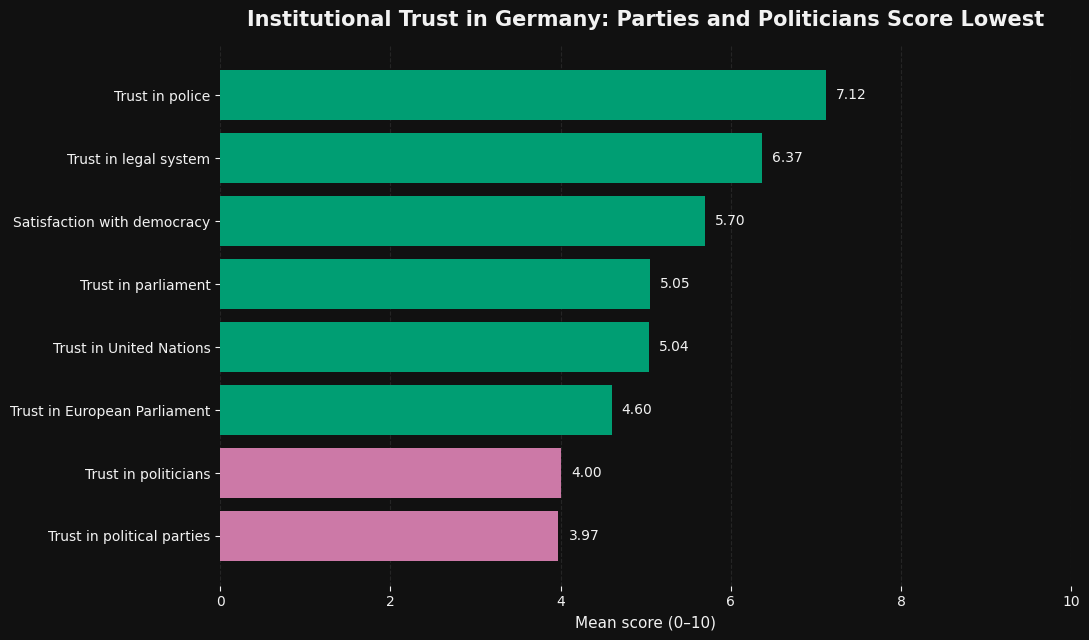

In [56]:
# 51.1 Visualize institutional trust ranking with accessible dark theme

import matplotlib.pyplot as plt
from pathlib import Path

viz_path = Path("../visualizations")
viz_path.mkdir(parents=True, exist_ok=True)

trust_vars = [
    "stfdem",
    "trstprl",
    "trstplt",
    "trstprt",
    "trstlgl",
    "trstplc",
    "trstep",
    "trstun"
]

trust_labels = {
    "stfdem": "Satisfaction with democracy",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties",
    "trstlgl": "Trust in legal system",
    "trstplc": "Trust in police",
    "trstep": "Trust in European Parliament",
    "trstun": "Trust in United Nations"
}

trust_summary = (
    df_de[trust_vars]
    .mean()
    .rename("mean")
    .reset_index()
    .rename(columns={"index": "variable"})
)

trust_summary["label"] = trust_summary["variable"].map(trust_labels)
trust_summary = trust_summary.sort_values("mean", ascending=True)

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"
purple = "#CC79A7"
teal = "#009E73"
yellow = "#F0E442"

colors = [
    purple if var in ["trstprt", "trstplt"] else teal
    for var in trust_summary["variable"]
]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

bars = ax.barh(trust_summary["label"], trust_summary["mean"], color=colors)

ax.set_title(
    "Institutional Trust in Germany: Parties and Politicians Score Lowest",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 10)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar, value in zip(bars, trust_summary["mean"]):
    ax.text(
        value + 0.12,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        color=text_col,
        fontsize=10
    )

plt.tight_layout()
plt.savefig(viz_path / "01_institutional_trust_ranking_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### 51.2 Political efficacy gap

This visualization compares democratic satisfaction and institutional trust across groups with low, medium and high perceived political efficacy.

Political efficacy describes whether respondents feel that people can have a say in politics, influence politics, and participate politically.

The goal is to test visually whether lower perceived political influence is associated with lower democratic satisfaction and lower institutional trust. The analysis is exploratory and does not imply causality.

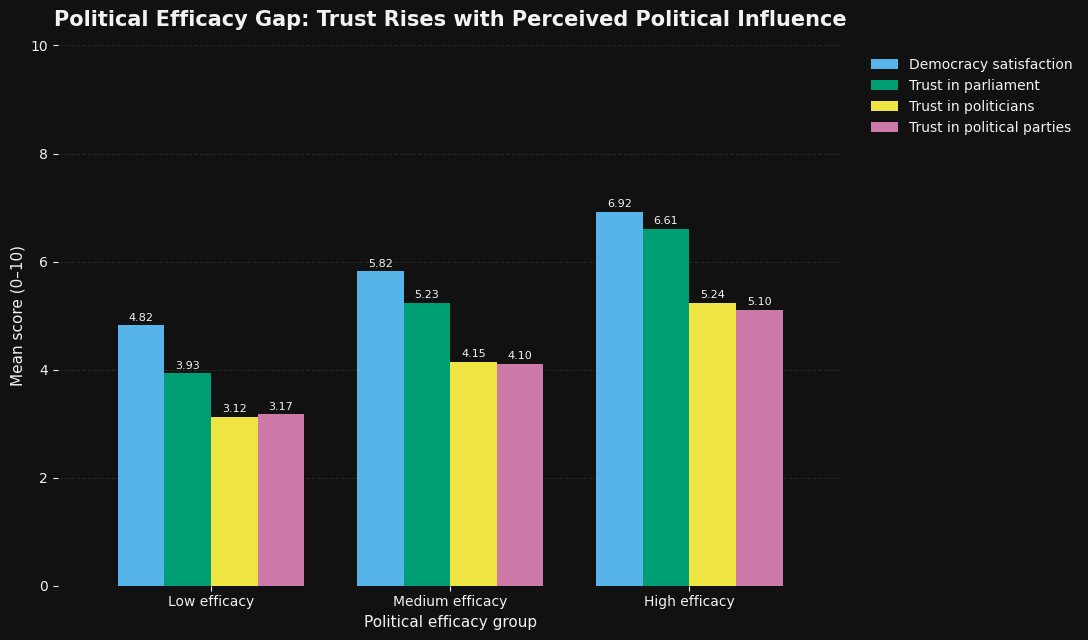

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties
efficacy_group,,,,
Low efficacy,4.82,3.93,3.12,3.17
Medium efficacy,5.82,5.23,4.15,4.10
High efficacy,6.92,6.61,5.24,5.10


In [57]:
# 51.2 Visualize democratic trust by political efficacy group with accessible dark theme

efficacy_plot = (
    df_de.groupby("efficacy_group", observed=False)[
        ["stfdem", "trstprl", "trstplt", "trstprt"]
    ]
    .mean()
    .round(2)
)

efficacy_plot = efficacy_plot.rename(columns={
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties"
})

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

palette = ["#56B4E9", "#009E73", "#F0E442", "#CC79A7"]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

efficacy_plot.plot(
    kind="bar",
    ax=ax,
    color=palette,
    width=0.78
)

ax.set_title(
    "Political Efficacy Gap: Trust Rises with Perceived Political Influence",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Political efficacy group", color=text_col, fontsize=11)
ax.set_ylabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylim(0, 10)

ax.tick_params(axis="x", colors=text_col, rotation=0)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

for text in legend.get_texts():
    text.set_color(text_col)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", color=text_col, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(viz_path / "02_political_efficacy_gap_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

efficacy_plot

### 51.3 Social trust gap

This visualization compares democratic satisfaction and institutional trust across respondents with low, medium and high social trust.

The social trust index is based on three ESS variables: whether people can be trusted, whether people are fair, and whether people are helpful.

The goal is to explore whether democratic trust is linked to broader social confidence. This is conceptually important because democratic trust may not only depend on institutions, but also on how people perceive society and other citizens.

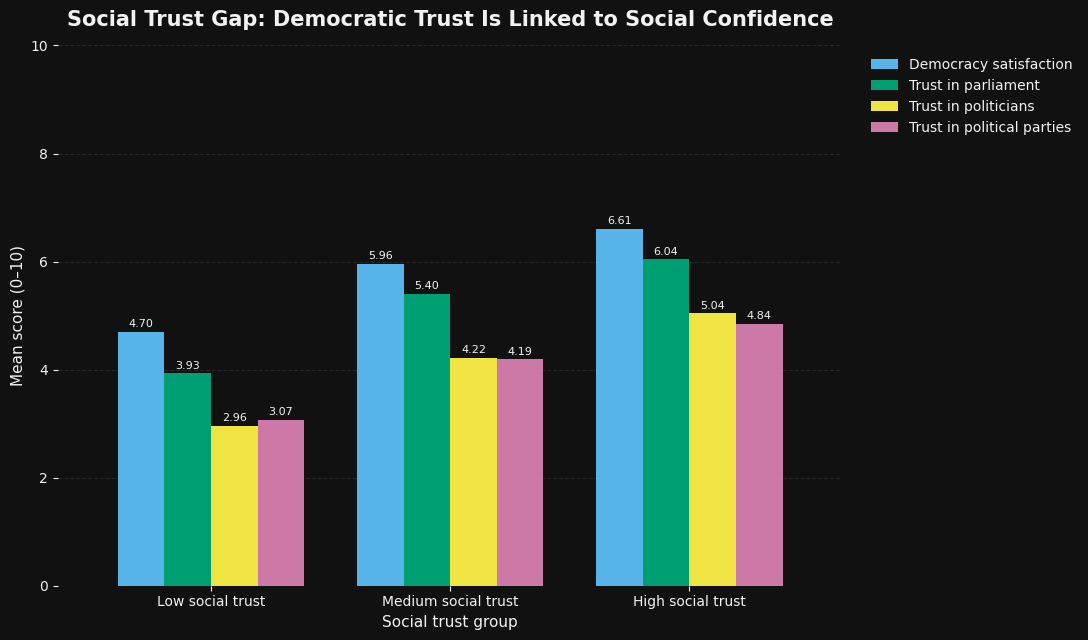

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties
social_trust_group,,,,
Low social trust,4.70,3.93,2.96,3.07
Medium social trust,5.96,5.40,4.22,4.19
High social trust,6.61,6.04,5.04,4.84


In [58]:
# 51.3 Visualize democratic trust by social trust group with accessible dark theme

social_plot = (
    df_de.groupby("social_trust_group", observed=False)[
        ["stfdem", "trstprl", "trstplt", "trstprt"]
    ]
    .mean()
    .round(2)
)

social_plot = social_plot.rename(columns={
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties"
})

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

palette = ["#56B4E9", "#009E73", "#F0E442", "#CC79A7"]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

social_plot.plot(
    kind="bar",
    ax=ax,
    color=palette,
    width=0.78
)

ax.set_title(
    "Social Trust Gap: Democratic Trust Is Linked to Social Confidence",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Social trust group", color=text_col, fontsize=11)
ax.set_ylabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylim(0, 10)

ax.tick_params(axis="x", colors=text_col, rotation=0)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

for text in legend.get_texts():
    text.set_color(text_col)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", color=text_col, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(viz_path / "03_social_trust_gap_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

social_plot

-> Preliminary interpretation: Democratic trust appears to be linked not only to institutions, but also to broader social confidence.

### 51.4 Participation gap

This visualization compares democratic satisfaction and institutional trust between respondents who voted and respondents who did not vote in the last national election.

The goal is to explore whether non-voting is associated with weaker democratic connection. This is strategically relevant because non-voters should not only be understood as missing votes, but potentially as a group with lower institutional trust and weaker political connection.

The analysis is exploratory and does not imply causality.

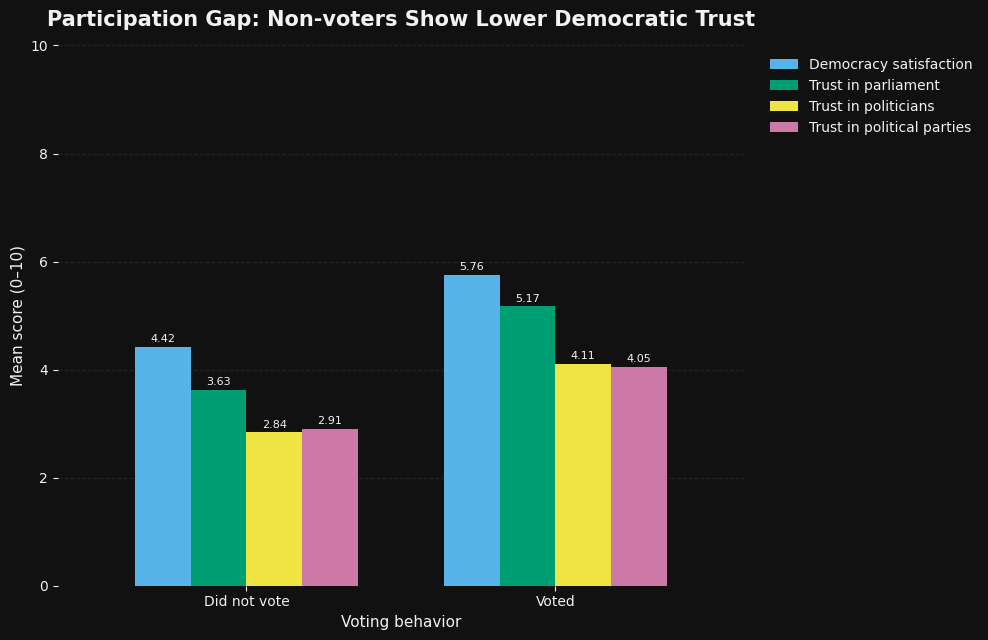

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties
vote_clean,,,,
Did not vote,4.42,3.63,2.84,2.91
Voted,5.76,5.17,4.11,4.05


In [59]:
# 51.4 Visualize democratic trust by voting behavior with accessible dark theme

vote_plot = (
    df_core.groupby("vote_clean")[
        ["stfdem", "trstprl", "trstplt", "trstprt"]
    ]
    .mean()
    .round(2)
)

vote_plot = vote_plot.rename(columns={
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties"
})

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

palette = ["#56B4E9", "#009E73", "#F0E442", "#CC79A7"]

fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

vote_plot.plot(
    kind="bar",
    ax=ax,
    color=palette,
    width=0.72
)

ax.set_title(
    "Participation Gap: Non-voters Show Lower Democratic Trust",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Voting behavior", color=text_col, fontsize=11)
ax.set_ylabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylim(0, 10)

ax.tick_params(axis="x", colors=text_col, rotation=0)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

for text in legend.get_texts():
    text.set_color(text_col)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", color=text_col, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(viz_path / "04_participation_gap_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

vote_plot

-> Preliminary interpretation: Non-voters are not only missing votes. In this dataset, they also show lower democratic satisfaction and lower institutional trust.